# Model for multiclass classification - 1st model on colour, 2nd model on faulty

Same classes: <br>
**1. blue <br>**
**2. cyan <br>**
**3. green <br>**
**4. orange <br>**
**5. pink <br>**
**6. red <br>**
**7. white <br>**
**8. yellow <br>**

But now model 1 takes in 8 colour classes
Model 2 takes in 2, faulty or not faulty (clean colour classes)

Dataset is still inclusive of dark and bright datasets

In [ ]:
from pathlib import Path

# Defining directories
base_dir = Path.home() / "Documents" / "duo_model_dataset" / "multiclass_colour"
base_dir

WindowsPath('C:/Users/Yin Yu/Documents/duo_model_dataset/multiclass_colour')

# Part one: Multiclass model

## 1. Exploratory Data Analysis

In [2]:
# Visualizing numbers per class per folder

# Define folders to analyze
subfolders = ["test_data", "train_data", "val_data"]

# Store results
class_counts = {}
total_counts = {}

# Loop for counts
for sub in subfolders:
    data_path = base_dir / sub
    class_counts[sub] = {}
    total_counts[sub] = 0
    for class_dir in data_path.iterdir():
        if class_dir.is_dir():
            num_files = len(list(class_dir.glob("*.*")))
            class_counts[sub][class_dir.name] = num_files
            total_counts[sub] += num_files

for sub in subfolders:
    print(f"{sub}: {class_counts[sub]}")

total_counts

test_data: {'blue': 60, 'cyan': 60, 'green': 60, 'orange': 55, 'pink': 55, 'red': 55, 'white': 55, 'yellow': 55}
train_data: {'blue': 283, 'cyan': 273, 'green': 267, 'orange': 266, 'pink': 266, 'red': 266, 'white': 258, 'yellow': 258}
val_data: {'blue': 60, 'cyan': 60, 'green': 60, 'orange': 55, 'pink': 55, 'red': 55, 'white': 55, 'yellow': 55}


{'test_data': 455, 'train_data': 2137, 'val_data': 455}

## 2. Data Augmentation (On-the-fly)

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 224
batch_size = 32

base_dir = Path.home() / "Documents" / "duo_model_dataset" / "multiclass_colour"
train_dir = base_dir / "train_data"
val_dir = base_dir / "val_data"
test_dir = base_dir / "test_data"

train_datagen = ImageDataGenerator(
    rescale=1./255,             # normalization
    rotation_range=20,          # mild rotations (since already did up to 360)
    brightness_range=[0.9, 1.1],  # small brightness tweaks
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=5,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)  # no augmentation for val/test

train_generator = train_datagen.flow_from_directory(
    directory=str(train_dir),
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'  # ensures one-hot encoding
)

val_generator = val_datagen.flow_from_directory(
    directory=str(val_dir),
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = val_datagen.flow_from_directory(
    directory=str(test_dir),
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False 
)

Found 2137 images belonging to 8 classes.
Found 455 images belonging to 8 classes.
Found 455 images belonging to 8 classes.


In [4]:
print("Class Indices (One-Hot Mapping):")
print(test_generator.class_indices)

Class Indices (One-Hot Mapping):
{'blue': 0, 'cyan': 1, 'green': 2, 'orange': 3, 'pink': 4, 'red': 5, 'white': 6, 'yellow': 7}


## 3. Model Training

In [6]:
import os
import json
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
import math
import numpy as np
from pathlib import Path
from sklearn.utils.class_weight import compute_class_weight

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),  # Dropout to prevent overfitting
    layers.Dense(train_generator.num_classes, activation='softmax')  # Output layer for classification
])

loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05)

# Compile Model
model.compile(
    optimizer='adam',
    loss=loss,
    metrics=['accuracy']
)

# Early Stopping Callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

# # Custom manual tweaks to improve distinction from faulty
# class_weight_dict = {
#     0: 0.95,  # blue
#     1: 0.99,  # cyan
#     2: 0.98,  # faulty — reduced to discourage over-prediction
#     3: 1.01,  # green
#     4: 1.10,  # orange ↑
#     5: 1.10,  # pink   ↑
#     6: 1.10,  # red    ↑
#     7: 1.05,  # white
#     8: 1.10   # yellow ↑
# }

# Checkpoint to use model with best weights
checkpoint_path = "../models/checkpoints/colour_best_model.h5"
checkpoint_cb = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False  # Set to False to save the full model
)

# Train Model
history = model.fit(
    train_generator,
    steps_per_epoch = math.ceil(train_generator.samples / train_generator.batch_size),
    epochs=20,
    validation_data=val_generator,
    validation_steps = math.ceil(val_generator.samples / val_generator.batch_size),
    callbacks=[early_stopping, checkpoint_cb],
    class_weight=dict(enumerate(class_weights)),
)

# Load the best model (based on val_loss)
best_model = tf.keras.models.load_model(checkpoint_path)

# Evaluate the best model
val_loss, val_accuracy = best_model.evaluate(val_generator)
print(f"Best Validation Loss: {val_loss}")
print(f"Best Validation Accuracy: {val_accuracy}")

# Optionally save again under a preferred name
best_model.save('../models/multiclass_duo_model.h5')

# Get the parent folder of the current script
parent_dir = Path.cwd().parent

# Define the metrics folder path at the same level as the parent
metrics_path = os.path.join(parent_dir, "metrics") # joins "metrics" to it → puts the folder beside the parent
os.makedirs(metrics_path, exist_ok=True)

# Define metrics folder for multiclass_img2
subfolder_path = os.path.join(metrics_path, "multiclass_duo")
os.makedirs(subfolder_path, exist_ok=True)

# Save file there
with open(os.path.join(metrics_path, "multiclass_duo/multiclass_duo_model.json"), "w") as f:
    json.dump(history.history, f)

Epoch 1/20
67/67 [==============================] - 124s 2s/step - loss: 1.5914 - accuracy: 0.4839 - val_loss: 0.6153 - val_accuracy: 0.9077
Epoch 2/20
67/67 [==============================] - 92s 1s/step - loss: 0.5765 - accuracy: 0.9275 - val_loss: 0.4593 - val_accuracy: 0.9890
Epoch 3/20
67/67 [==============================] - 95s 1s/step - loss: 0.4474 - accuracy: 0.9738 - val_loss: 0.4821 - val_accuracy: 0.9495
Epoch 4/20
67/67 [==============================] - 92s 1s/step - loss: 0.4258 - accuracy: 0.9729 - val_loss: 0.4504 - val_accuracy: 0.9714
Epoch 5/20
67/67 [==============================] - 94s 1s/step - loss: 0.3645 - accuracy: 0.9930 - val_loss: 0.3549 - val_accuracy: 0.9890
Epoch 6/20
67/67 [==============================] - 94s 1s/step - loss: 0.3505 - accuracy: 0.9939 - val_loss: 0.3405 - val_accuracy: 0.9978
Epoch 7/20
67/67 [==============================] - 94s 1s/step - loss: 0.3415 - accuracy: 0.9920 - val_loss: 0.3201 - val_accuracy: 0.9978
Epoch 8/20
67/67 [=

## 4. Model Evaluation

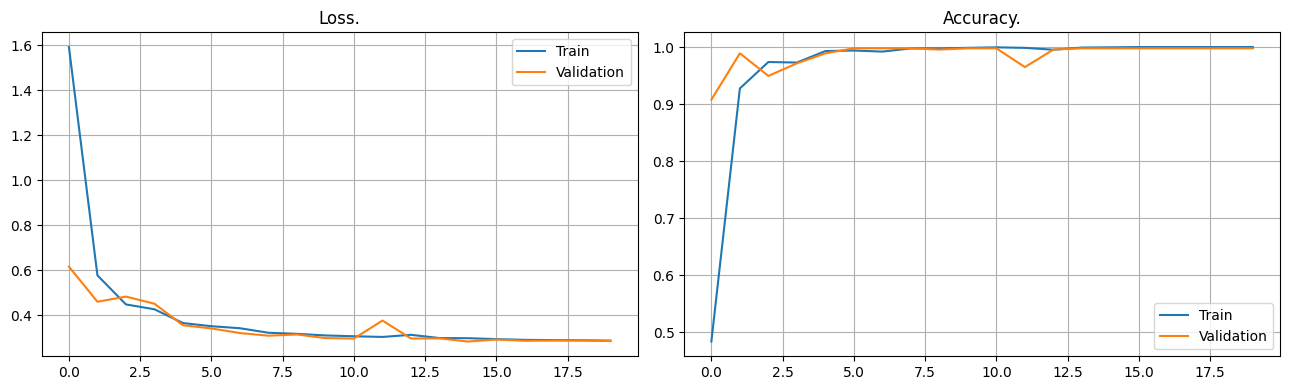

In [7]:
# Extracting metrics

import matplotlib.pyplot as plt

metrics = history.history

train_loss = metrics["loss"]
train_accuracy = metrics["accuracy"]

validation_loss = metrics["val_loss"]
validation_accuracy = metrics["val_accuracy"]

# Visualizing metrics
plt.figure(figsize = (13,4))
plt.subplot(1,2,1)
plt.title("Loss.")
plt.plot(train_loss, label = "Train")
plt.plot(validation_loss, label = "Validation")
plt.grid(True)
plt.legend(loc = "best")

plt.subplot(1,2,2)
plt.title("Accuracy.")
plt.plot(train_accuracy, label = "Train")
plt.plot(validation_accuracy, label = "Validation")
plt.grid(True)
plt.legend(loc = "best")

# Save the figure
plt.tight_layout()
plt.savefig("../metrics/multiclass_duo/multiclass_duo_model.png")
plt.show()
plt.close()

15/15 [==============================] - 19s 1s/step


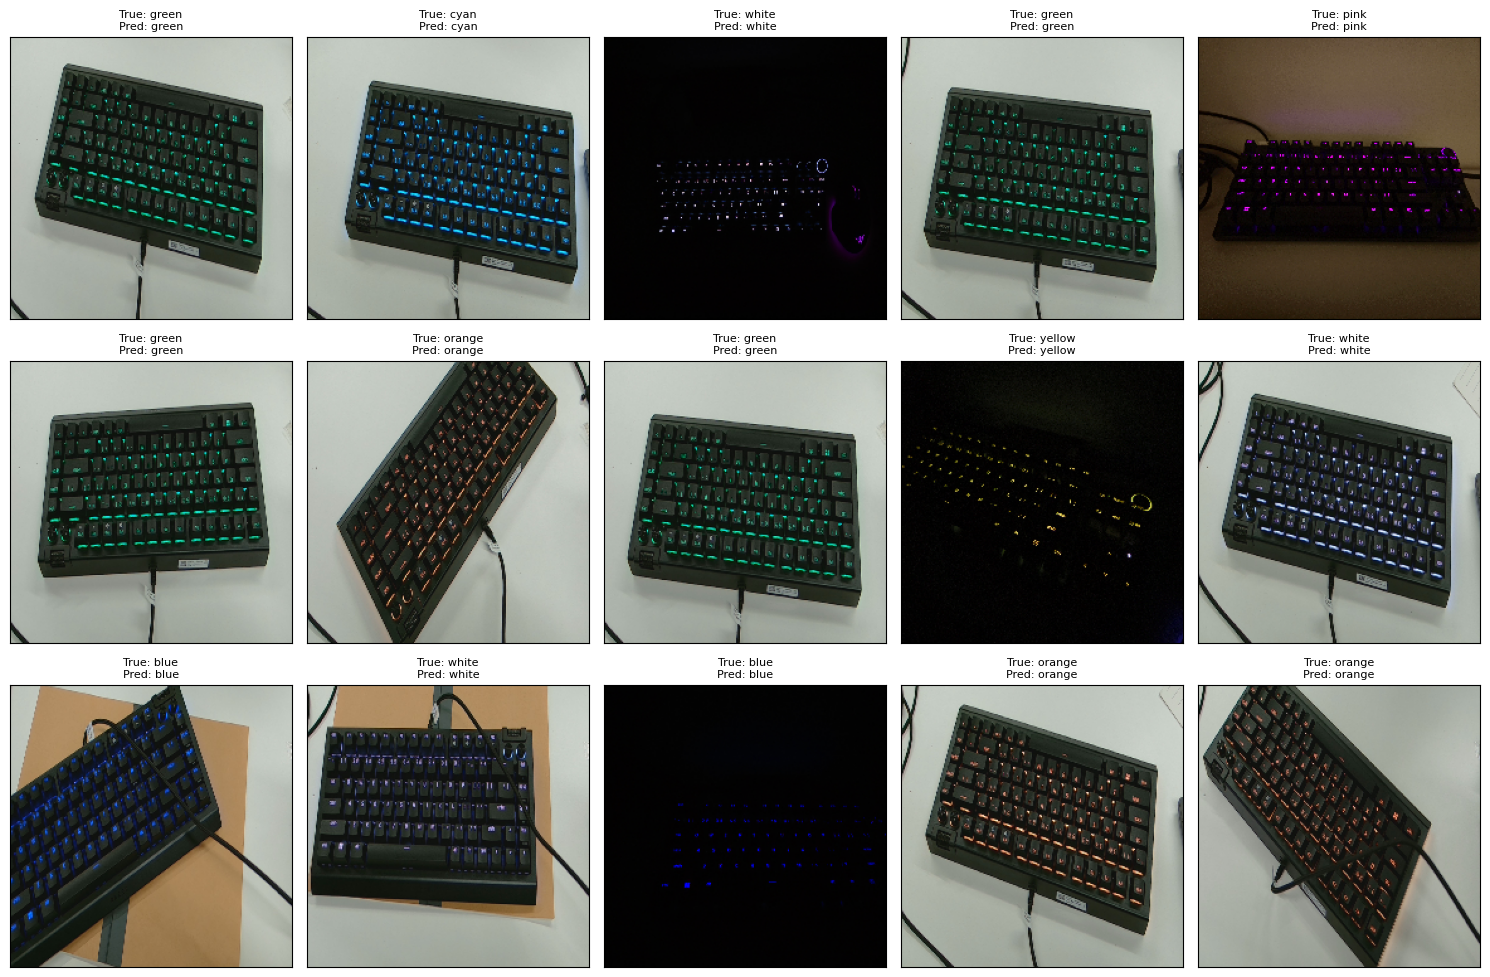

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Reset the generator to ensure predictions align
test_generator.reset()

# Get predictions on the full test set
result = best_model.predict(test_generator, verbose=1)
predicted_class = np.argmax(result, axis=1)
true_class = test_generator.classes
class_names = list(test_generator.class_indices.keys())
batch_size = test_generator.batch_size

# Choose random indices within the test set
num_random_images = 15
random_indices = np.random.choice(len(true_class), size=num_random_images, replace=False)

# Load all image batches from the generator (this gives us images in order)
all_images = []
for i in range(len(test_generator)):
    imgs, _ = test_generator[i]
    all_images.extend(imgs)

# Plot selected images with predictions
plt.figure(figsize=(15, 10))
for i, idx in enumerate(random_indices):
    img = all_images[idx]
    true_label_index = true_class[idx]
    predicted_label_index = predicted_class[idx]

    plt.subplot(3, 5, i + 1)
    plt.imshow(img)
    plt.xticks([]), plt.yticks([])
    plt.title(f"True: {class_names[true_label_index]}\nPred: {class_names[predicted_label_index]}", fontsize=8)

plt.tight_layout()
plt.show()

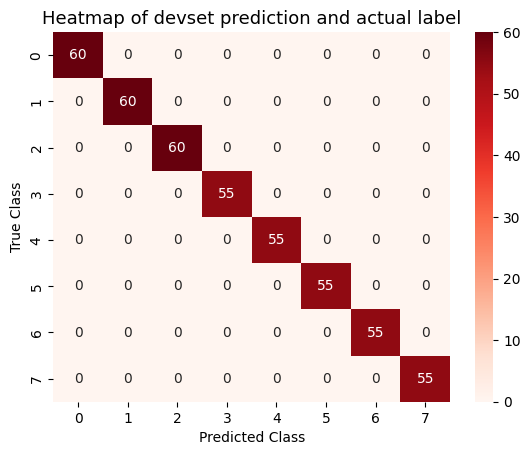

In [9]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculating confusion matrix
plt.title("Heatmap of devset prediction and actual label", fontsize = 13)
cm = confusion_matrix(true_class, predicted_class)
sns.heatmap(cm, cmap = "Reds", annot = True, fmt = "d")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")

# Save heatmap image
plt.savefig("../metrics/multiclass_duo/multiclass_duo_model.png")
plt.show()
plt.close()

In [10]:
from sklearn.metrics import classification_report

# Understanding classification power of model on each class
report = classification_report(true_class, predicted_class)
print(report)

# Save it
with open(os.path.join(metrics_path, "multiclass_duo/multiclass_duo_model.txt"), "w") as f:
    f.write(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        60
           1       1.00      1.00      1.00        60
           2       1.00      1.00      1.00        60
           3       1.00      1.00      1.00        55
           4       1.00      1.00      1.00        55
           5       1.00      1.00      1.00        55
           6       1.00      1.00      1.00        55
           7       1.00      1.00      1.00        55

    accuracy                           1.00       455
   macro avg       1.00      1.00      1.00       455
weighted avg       1.00      1.00      1.00       455



1/1 [==============================] - 0s 39ms/step


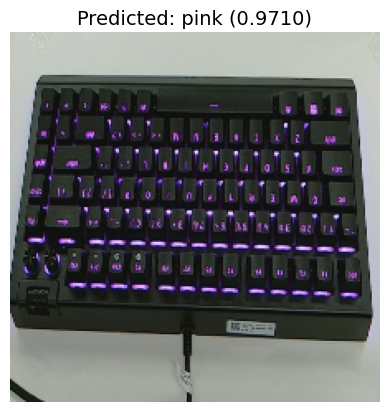

'pink'

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image as keras_image

# Constants
img_size = 224
class_indices = {'blue': 0, 'cyan': 1, 'green': 2, 'orange': 3, 'pink': 4, 'red': 5, 'white': 6, 'yellow': 7}

# Load the model
restored_model = tf.keras.models.load_model('../models/multiclass_duo_model.h5')

def predict_single_image(img_path, model, class_indices, img_size):
    # Load and preprocess image
    img = keras_image.load_img(img_path, target_size=(img_size, img_size))
    img_array = keras_image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict using the model (softmax expected)
    prediction = model.predict(img_array)[0]  # Shape: (num_classes,)
    predicted_index = np.argmax(prediction)
    predicted_prob = prediction[predicted_index]

    # Convert index back to class label
    index_to_class = {v: k for k, v in class_indices.items()}
    predicted_label = index_to_class[predicted_index]

    # Show image and prediction
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicted: {predicted_label} ({predicted_prob:.4f})", fontsize=14)
    plt.show()

    return predicted_label

# Set your image path
img_path = r"C:\Users\Yin Yu\Documents\cv_automation\Robot\pictures\photo (8).jpg"

# Run prediction
predict_single_image(img_path, restored_model, class_indices, img_size)

# Part two: Binary class model

## 1. Exploratory data analysis

In [3]:
from pathlib import Path

# Defining directories
base_duo_dir = Path.home() / "Documents" / "duo_model_dataset" / "binary_faulty"
base_duo_dir

WindowsPath('C:/Users/Yin Yu/Documents/duo_model_dataset/binary_faulty')

## 1. Exploratory Data Analysis

In [4]:
# Visualizing numbers per class per folder

# Define folders to analyze
duo_subfolders = ["test_data", "train_data", "val_data"]

# Store results
duo_class_counts = {}
duo_total_counts = {}

# Loop for counts
for sub in duo_subfolders:
    data_path = base_duo_dir / sub
    duo_class_counts[sub] = {}
    duo_total_counts[sub] = 0
    for class_dir in data_path.iterdir():
        if class_dir.is_dir():
            num_files = len(list(class_dir.glob("*.*")))
            duo_class_counts[sub][class_dir.name] = num_files
            duo_total_counts[sub] += num_files

for sub in duo_subfolders:
    print(f"{sub}: {duo_class_counts[sub]}")

duo_total_counts

test_data: {'clean': 73, 'faulty': 74}
train_data: {'clean': 393, 'faulty': 366}
val_data: {'clean': 125, 'faulty': 104}


{'test_data': 147, 'train_data': 759, 'val_data': 229}

## 2. Data Augmentation (On-the-fly)

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 224
batch_size = 32

base_duo_dir = Path.home() / "Documents" / "duo_model_dataset" / "binary_faulty"
duo_train_dir = base_duo_dir / "train_data"
duo_val_dir = base_duo_dir / "val_data"
duo_test_dir = base_duo_dir / "test_data"

train_datagen = ImageDataGenerator(
    rescale=1./255,             # normalization
    rotation_range=20,          # mild rotations (since already did up to 360)
    brightness_range=[0.9, 1.1],  # small brightness tweaks
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=5,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)  # no augmentation for val/test

train_generator = train_datagen.flow_from_directory(
    directory=str(duo_train_dir),
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    directory=str(duo_val_dir),
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary'
)

test_generator = val_datagen.flow_from_directory(
    directory=str(duo_test_dir),
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False 
)

Found 759 images belonging to 2 classes.
Found 229 images belonging to 2 classes.
Found 147 images belonging to 2 classes.


In [6]:
print("Class Indices (One-Hot Mapping):")
print(test_generator.class_indices)

Class Indices (One-Hot Mapping):
{'clean': 0, 'faulty': 1}


## 3. Model Training

In [9]:
import os
import json
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
import math
import numpy as np
from pathlib import Path
from sklearn.utils.class_weight import compute_class_weight

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),  # Dropout to prevent overfitting
    layers.Dense(1, activation='sigmoid')  # Output layer for binary
])

loss = 'binary_crossentropy'

# Compile Model
model.compile(
    optimizer='adam',
    loss=loss,
    metrics=['accuracy']
)

# Early Stopping Callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Class weights
# class_weights = compute_class_weight(
#     class_weight='balanced',
#     classes=np.unique(train_generator.classes),
#     y=train_generator.classes
# )
# class_weight_dict = dict(enumerate(class_weights))

# Checkpoint to use model with best weights
checkpoint_path = "../models/checkpoints/binary_best_model.h5"
checkpoint_cb = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False  # Set to False to save the full model
)

# Train Model
history = model.fit(
    train_generator,
    steps_per_epoch = math.ceil(train_generator.samples / train_generator.batch_size),
    epochs=20,
    validation_data=val_generator,
    validation_steps = math.ceil(val_generator.samples / val_generator.batch_size),
    callbacks=[early_stopping, checkpoint_cb],
    # class_weight=class_weight_dict,
)

# Load the best model (based on val_loss)
best_model = tf.keras.models.load_model(checkpoint_path)

# Evaluate the best model
val_loss, val_accuracy = best_model.evaluate(val_generator)
print(f"Best Validation Loss: {val_loss}")
print(f"Best Validation Accuracy: {val_accuracy}")

# Optionally save again under a preferred name
best_model.save('../models/binary_model4.h5')

# Get the parent folder of the current script
parent_dir = Path.cwd().parent

# Define the metrics folder path at the same level as the parent
metrics_path = os.path.join(parent_dir, "metrics") # joins "metrics" to it → puts the folder beside the parent
os.makedirs(metrics_path, exist_ok=True)

# Define metrics folder
subfolder_path = os.path.join(metrics_path, "multiclass_duo")
os.makedirs(subfolder_path, exist_ok=True)

# Save file there
with open(os.path.join(metrics_path, "multiclass_duo/binary_model7.json"), "w") as f:
    json.dump(history.history, f)

Epoch 1/20
24/24 [==============================] - 61s 3s/step - loss: 1.2186 - accuracy: 0.5231 - val_loss: 0.6886 - val_accuracy: 0.5459
Epoch 2/20
24/24 [==============================] - 69s 3s/step - loss: 0.6809 - accuracy: 0.5731 - val_loss: 0.6723 - val_accuracy: 0.5764
Epoch 3/20
24/24 [==============================] - 69s 3s/step - loss: 0.6556 - accuracy: 0.6377 - val_loss: 0.6284 - val_accuracy: 0.6987
Epoch 4/20
24/24 [==============================] - 76s 3s/step - loss: 0.5974 - accuracy: 0.6957 - val_loss: 0.5906 - val_accuracy: 0.6769
Epoch 5/20
24/24 [==============================] - 73s 3s/step - loss: 0.5631 - accuracy: 0.7009 - val_loss: 0.5995 - val_accuracy: 0.6638
Epoch 6/20
24/24 [==============================] - 59s 2s/step - loss: 0.5453 - accuracy: 0.7391 - val_loss: 0.6207 - val_accuracy: 0.6638
Epoch 7/20
24/24 [==============================] - 34s 1s/step - loss: 0.5214 - accuracy: 0.7418 - val_loss: 0.5693 - val_accuracy: 0.6987
Epoch 8/20
24/24 [==

## 4. Model Evaluation

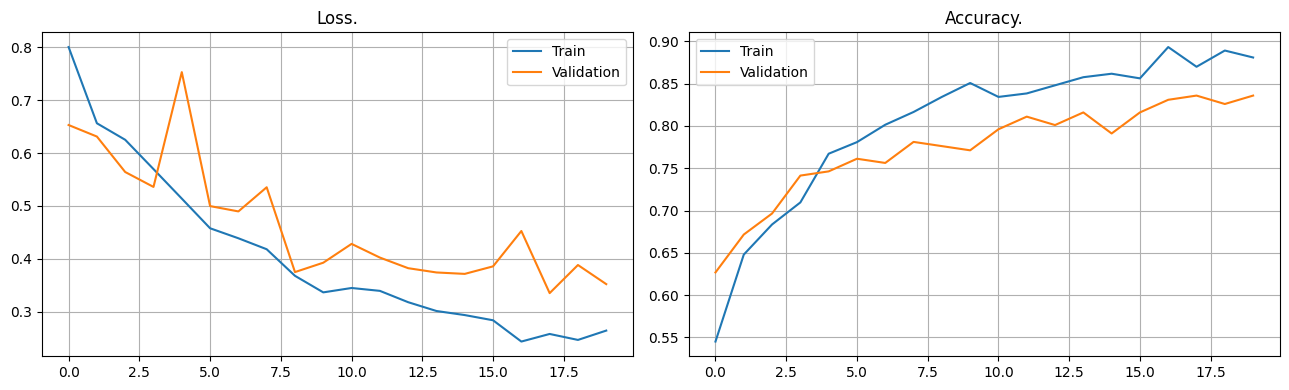

In [18]:
# Extracting metrics

import matplotlib.pyplot as plt

metrics = history.history

train_loss = metrics["loss"]
train_accuracy = metrics["accuracy"]

validation_loss = metrics["val_loss"]
validation_accuracy = metrics["val_accuracy"]

# Visualizing metrics
plt.figure(figsize = (13,4))
plt.subplot(1,2,1)
plt.title("Loss.")
plt.plot(train_loss, label = "Train")
plt.plot(validation_loss, label = "Validation")
plt.grid(True)
plt.legend(loc = "best")

plt.subplot(1,2,2)
plt.title("Accuracy.")
plt.plot(train_accuracy, label = "Train")
plt.plot(validation_accuracy, label = "Validation")
plt.grid(True)
plt.legend(loc = "best")

# Save the figure
plt.tight_layout()
plt.savefig("../metrics/multiclass_duo/binary_duo_model5.png")
plt.show()
plt.close()

5/5 [==============================] - 7s 1s/step


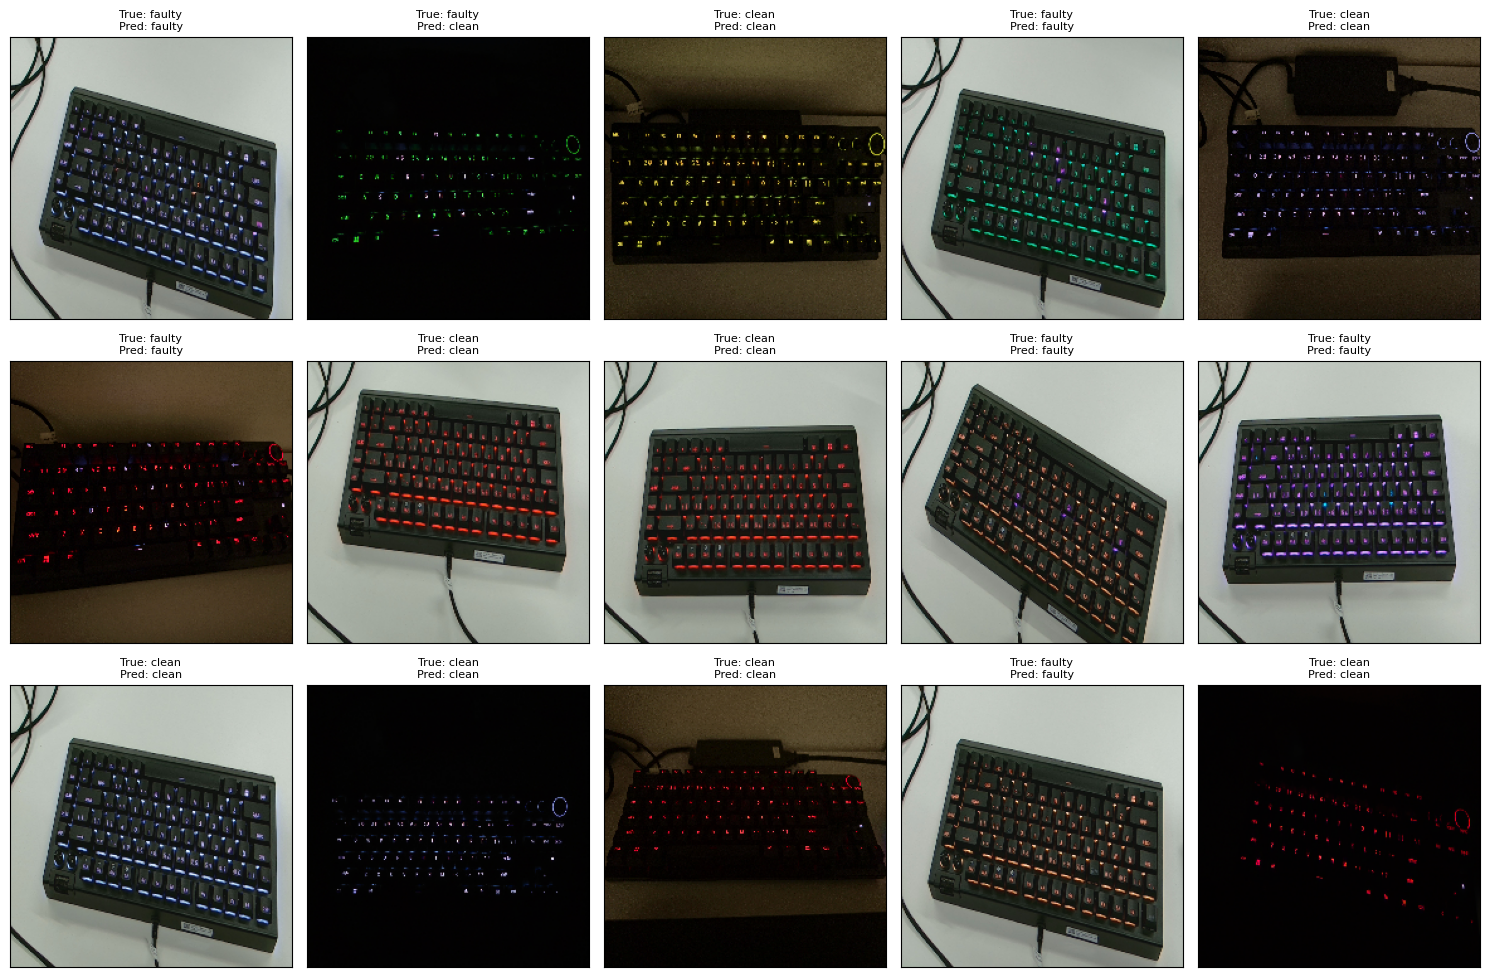

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Reset the generator to ensure predictions align
test_generator.reset()

# Get predictions on the full test set
result = best_model.predict(test_generator, verbose=1)
predicted_class = (result > 0.5).astype("int32").flatten()
true_class = test_generator.classes
class_names = list(test_generator.class_indices.keys())
batch_size = test_generator.batch_size

# Choose random indices within the test set
num_random_images = 15
random_indices = np.random.choice(len(true_class), size=num_random_images, replace=False)

# Load all image batches from the generator (this gives us images in order)
all_images = []
for i in range(len(test_generator)):
    imgs, _ = test_generator[i]
    all_images.extend(imgs)

# Plot selected images with predictions
plt.figure(figsize=(15, 10))
for i, idx in enumerate(random_indices):
    img = all_images[idx]
    true_label_index = true_class[idx]
    predicted_label_index = predicted_class[idx]

    plt.subplot(3, 5, i + 1)
    plt.imshow(img)
    plt.xticks([]), plt.yticks([])
    plt.title(f"True: {class_names[true_label_index]}\nPred: {class_names[predicted_label_index]}", fontsize=8)

plt.tight_layout()
plt.show()

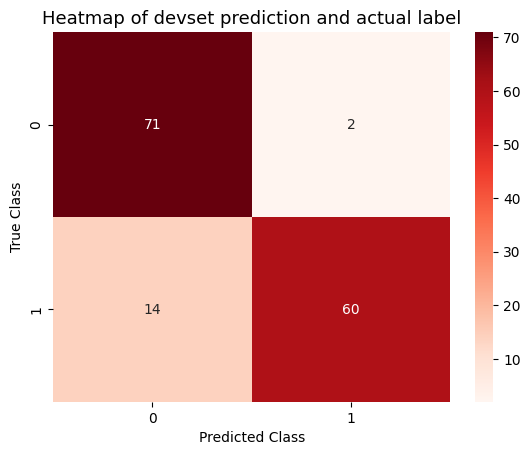

In [20]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculating confusion matrix
plt.title("Heatmap of devset prediction and actual label", fontsize = 13)
cm = confusion_matrix(true_class, predicted_class)
sns.heatmap(cm, cmap = "Reds", annot = True, fmt = "d")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")

# Save heatmap image
plt.savefig("../metrics/multiclass_duo/binary_duo_model5.png")
plt.show()
plt.close()

Total misclassified: 15


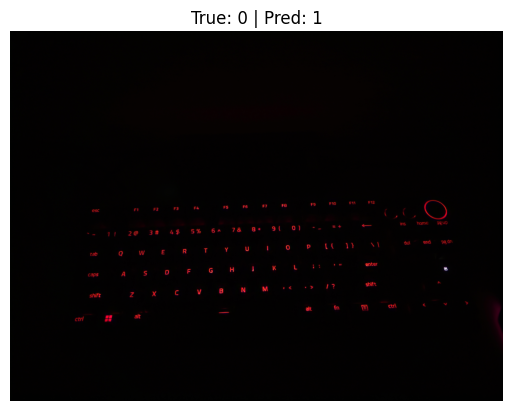

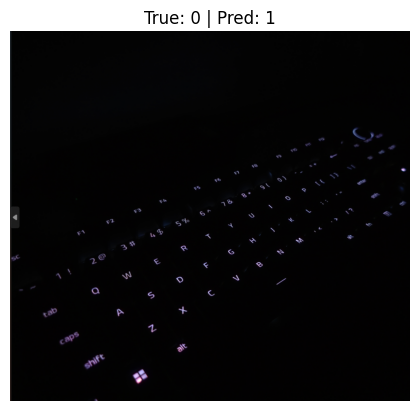

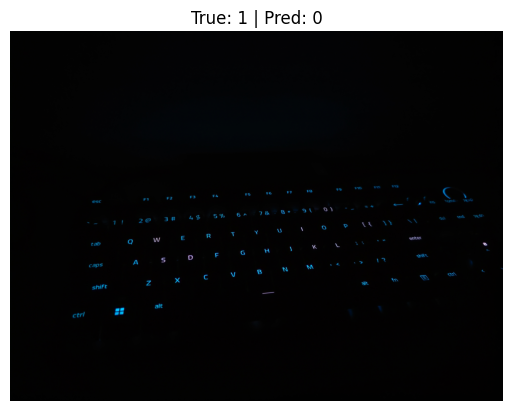

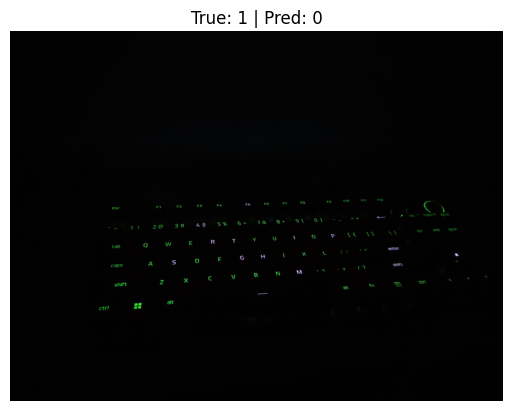

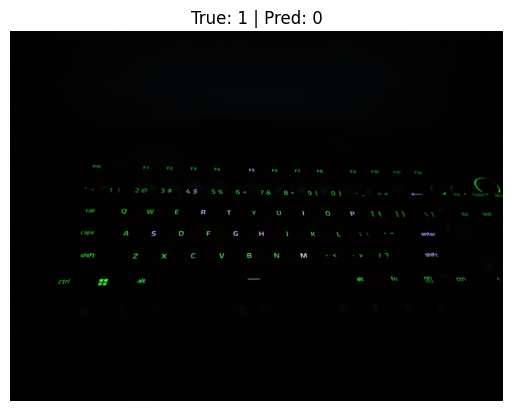

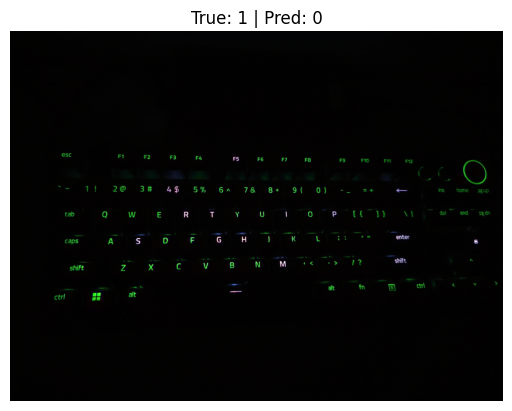

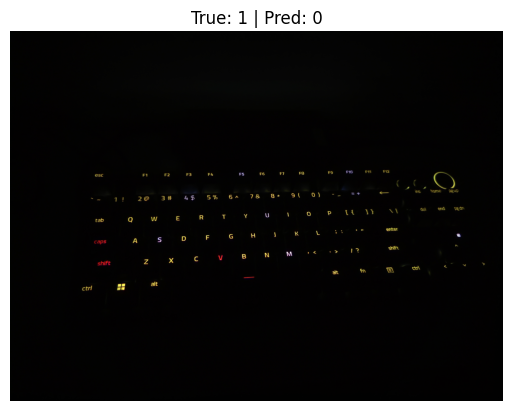

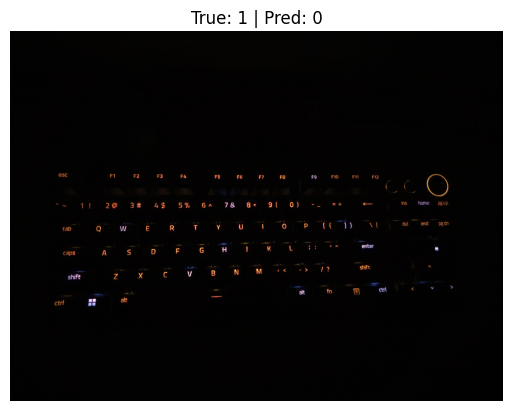

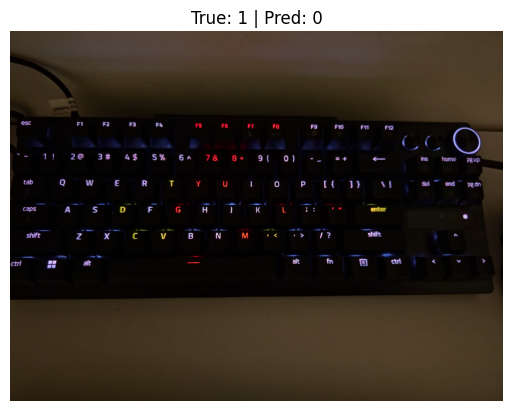

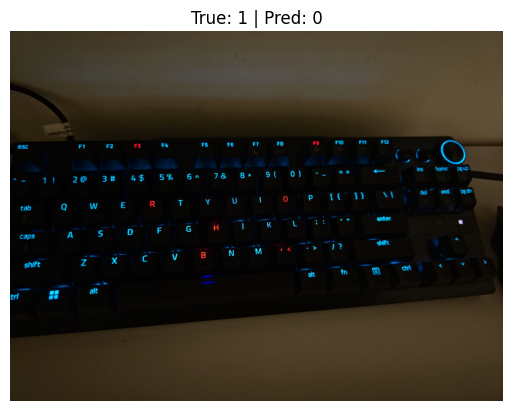

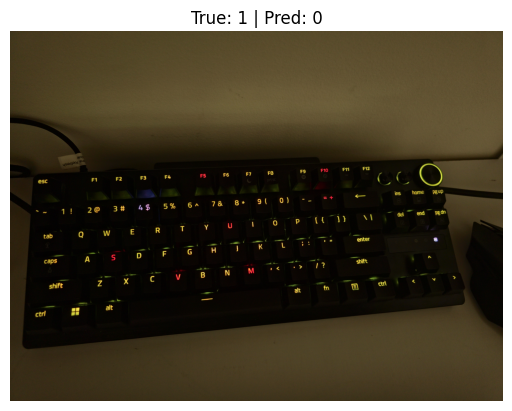

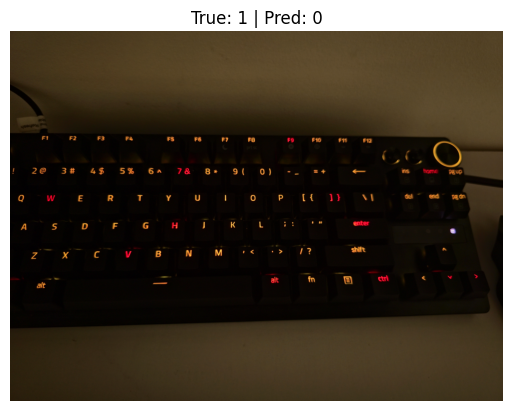

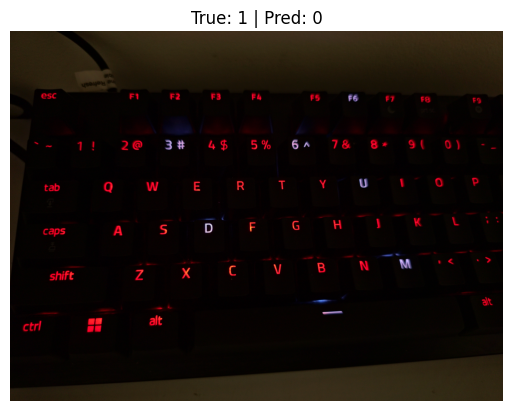

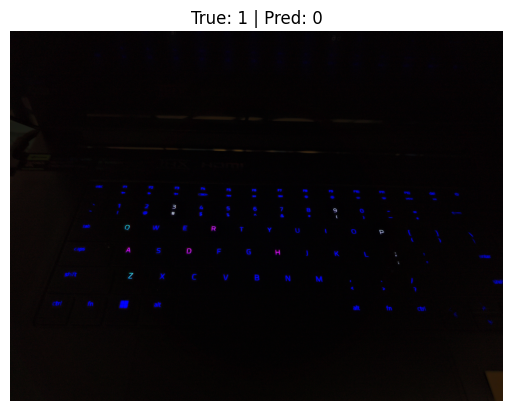

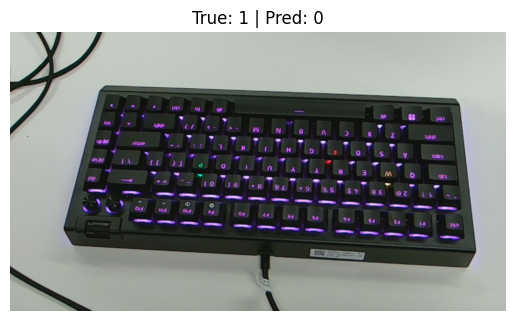

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

filenames = test_generator.filenames  # list of relative file paths (e.g. "clean/img001.jpg")

incorrect_indices = np.where(predicted_class != true_class)[0]
print(f"Total misclassified: {len(incorrect_indices)}")

base_path = test_generator.directory  # absolute base dir
for idx in incorrect_indices[:15]:   # show no.
    path = os.path.join(base_path, filenames[idx])
    img = mpimg.imread(path)
    plt.imshow(img)
    plt.title(f"True: {true_class[idx]} | Pred: {predicted_class[idx]}")
    plt.axis('off')
    plt.show()


1/1 [==============================] - 0s 45ms/step


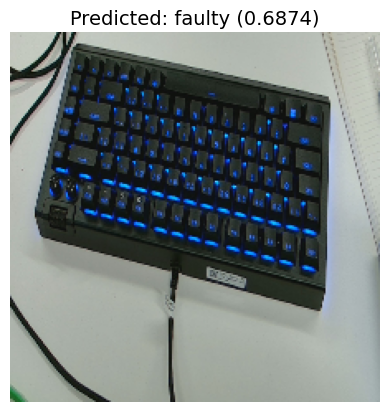

'faulty'

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image as keras_image

# Constants
img_size = 224
class_indices = {'clean': 0, 'faulty': 1}

# Load the model
restored_model = tf.keras.models.load_model('../models/binary_model4.h5')

def predict_single_image(img_path, model, class_indices, img_size, threshold=0.5):
    # Load and preprocess image
    img = keras_image.load_img(img_path, target_size=(img_size, img_size))
    img_array = keras_image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict using sigmoid output
    prediction = model.predict(img_array)
    prob = float(prediction[0][0])
    predicted_index = int(prob > threshold)

    # Convert index back to class label
    index_to_class = {v: k for k, v in class_indices.items()}
    predicted_label = index_to_class[predicted_index]

    # Show image and prediction
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicted: {predicted_label} ({prob:.4f})", fontsize=14)
    plt.show()

    return predicted_label

# Set your image path
img_path = r"C:\Users\Yin Yu\Documents\cv_automation\Robot\pictures\photo.jpg"

# Run prediction
predict_single_image(img_path, restored_model, class_indices, img_size)